In [1]:
import torch
from sorl.gat_sim import GAT, GATConfig, BOS_TOKEN_ID
torch.set_float32_matmul_precision('high')  # Enable TF32 for ~2x speedup
# For fast training, set 'BOS_TOKEN_ID' to 15 in 'sorl/gat_sim.py' 

gat_config = GATConfig(
    vocab_sizes=[BOS_TOKEN_ID+1, 6],  # 6 abstract tokens
    n_layer=4,
    n_head=4,
    n_embd=128,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

model = GAT(gat_config)
# model = model.to("cuda")
# model = torch.compile(model)

In [2]:
# ---- Copy & Paste Data Loader ----
from data.copy_paste import CopyPasteDataLoader
# for visualization purpose (seq_len=1 specific)
from data.copy_paste import extract_doc_components, collect_rollout_statistics, check_abs_logits, visualize_abstraction_dynamics

seq_len = 1
loader = CopyPasteDataLoader(vocab_size=9, max_token=9, seq_len=seq_len, device='cpu')
tokens, loss_mask = loader.get_batch(2)

# static config 
batch_size = 32
memory_span = 2 * seq_len + 2
attn_blocksize = 1792
max_iterations = 2
K = seq_len

In [3]:
# Dynamic Visualization of SoRL
# 1. select-one SoRL

from sorl.neo_utils import sorl_rollout_v2, compute_loss, select_best_per_doc, sorl_evaluate, compute_vocab_utilization_rate, compute_loss_with_entropy
from collections import defaultdict

# 1. per-digit abstraction logits 

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)
n = 2
temperature = torch.tensor([0.0, 5.0], device=model.device)
num_steps = 200 
alpha_loss = 0.1
alpha_entropy = 1.0
record = defaultdict(list)
img_frames = []

for step in range(num_steps): 

    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    with torch.no_grad(): 
        # --- breakdown of SoRL search (select one per-document) ---
        search_data, search_ppt = sorl_rollout_v2(tokens, model, n=n, K=K, 
                                    max_iterations=max_iterations,
                                    memory_span=memory_span,
                                    attn_blocksize=attn_blocksize,
                                    temperature=temperature,
                                    truncate_seq_len=False)
        search_ppt = search_ppt.reshape(search_data.shape[0], -1)

        levels = (search_data >= model.vocab_sizes[0]).long()
        best_data, best_ppt, best_ppt_advantage = select_best_per_doc(search_data, search_ppt, levels, model)

        greedy_stat, random_stat = collect_rollout_statistics(search_data, search_ppt, best_data, best_ppt, seq_len, BOS_TOKEN_ID)

    # --- compute loss --- 
    # traj_loss, abs_loss = compute_loss(search_data, model, memory_span, attn_blocksize) # all-rollout SoRL
    # traj_loss, abs_loss = compute_loss(best_data, model, memory_span, attn_blocksize) # select-one SoRL
    traj_loss, abs_loss, entropy_loss = compute_loss_with_entropy(best_data, model, memory_span, attn_blocksize) # select-one SoRL with entropy regularization
    # traj_loss, abs_loss, entropy_loss = compute_loss_with_entropy(search_data, model, memory_span, attn_blocksize) # all-rollout SoRL with entropy regularization


    loss = traj_loss + alpha_loss * abs_loss + alpha_entropy * entropy_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, 10.0], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss = sorl_evaluate(tokens, model, n=2, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            vocab_util = compute_vocab_utilization_rate(val_tokens, model)
            abs_probs = check_abs_logits(model, loader, memory_span, attn_blocksize)
            record['vocab_util'].append(vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['traj_loss'].append(traj_loss.item())
        print(f"\nvalidation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}%")
        
        img = visualize_abstraction_dynamics(greedy_stat, random_stat, abs_probs, step, vocab_size=10, num_abs=6, abs_offset=model.vocab_sizes[0].item())
        img_frames.append(img)


validation step 0 | traj_loss: 3.20 | abs_loss: 3.27 | search adv: 0.93% | vocab util: 83.33%

validation step 2 | traj_loss: 2.93 | abs_loss: 3.20 | search adv: 4.75% | vocab util: 83.33%

validation step 4 | traj_loss: 2.68 | abs_loss: 3.13 | search adv: 8.53% | vocab util: 83.33%

validation step 6 | traj_loss: 2.46 | abs_loss: 3.00 | search adv: 13.08% | vocab util: 83.33%

validation step 8 | traj_loss: 2.25 | abs_loss: 2.85 | search adv: 23.54% | vocab util: 83.33%

validation step 10 | traj_loss: 2.04 | abs_loss: 2.75 | search adv: 23.75% | vocab util: 83.33%

validation step 12 | traj_loss: 1.84 | abs_loss: 2.65 | search adv: 28.60% | vocab util: 83.33%

validation step 14 | traj_loss: 1.66 | abs_loss: 2.57 | search adv: 37.03% | vocab util: 83.33%

validation step 16 | traj_loss: 1.50 | abs_loss: 2.47 | search adv: 41.96% | vocab util: 83.33%

validation step 18 | traj_loss: 1.36 | abs_loss: 2.37 | search adv: 53.74% | vocab util: 83.33%

validation step 20 | traj_loss: 1.25 

In [ ]:
# Idea #1. Orthogonal initialization on abstract wte -- start differently

# Idea #2. Entropy regularization on logits (token-wise free bit method)
# -> Aligns with VAE's KL term, trying this first. 
# -> Need to extract logits for abstract tokens & compute entropy from there
# Implementation #2. Free-bit included entropy regularization

# Exp #1. Try out 'all-rollout' SoRL, now that we've fixed the compute loss function. 
# Obs #1. "posterior-collapse", no winner-take-all, but for all task, all abstraction has similar utility, and they get selected with similar logits
#         this basically means p(a | s) does not contain meaningful information, and p(s | a) is simply not using abstraction's encoded information. 

# Exp #2. Try out free-bit entropy regularization, starting with 'unlimited' entropy regularization, with parameter 'beta' to tune its strength
#       - We can try it out on server runs, smaller-scale experiments can hardly reveal the optimal config, only the general trend. 

# Exp #3. 

In [4]:
if len(img_frames) > 0:
    img_frames[0].save(
        'abstraction_dynamics (all-rollout SoRL with entropy regularization).gif',
        save_all=True,
        append_images=img_frames[1:],
        duration=500,  # milliseconds per frame
        loop=0  # 0 = infinite loop
    )
    print(f"Saved GIF with {len(img_frames)} frames")

Saved GIF with 100 frames


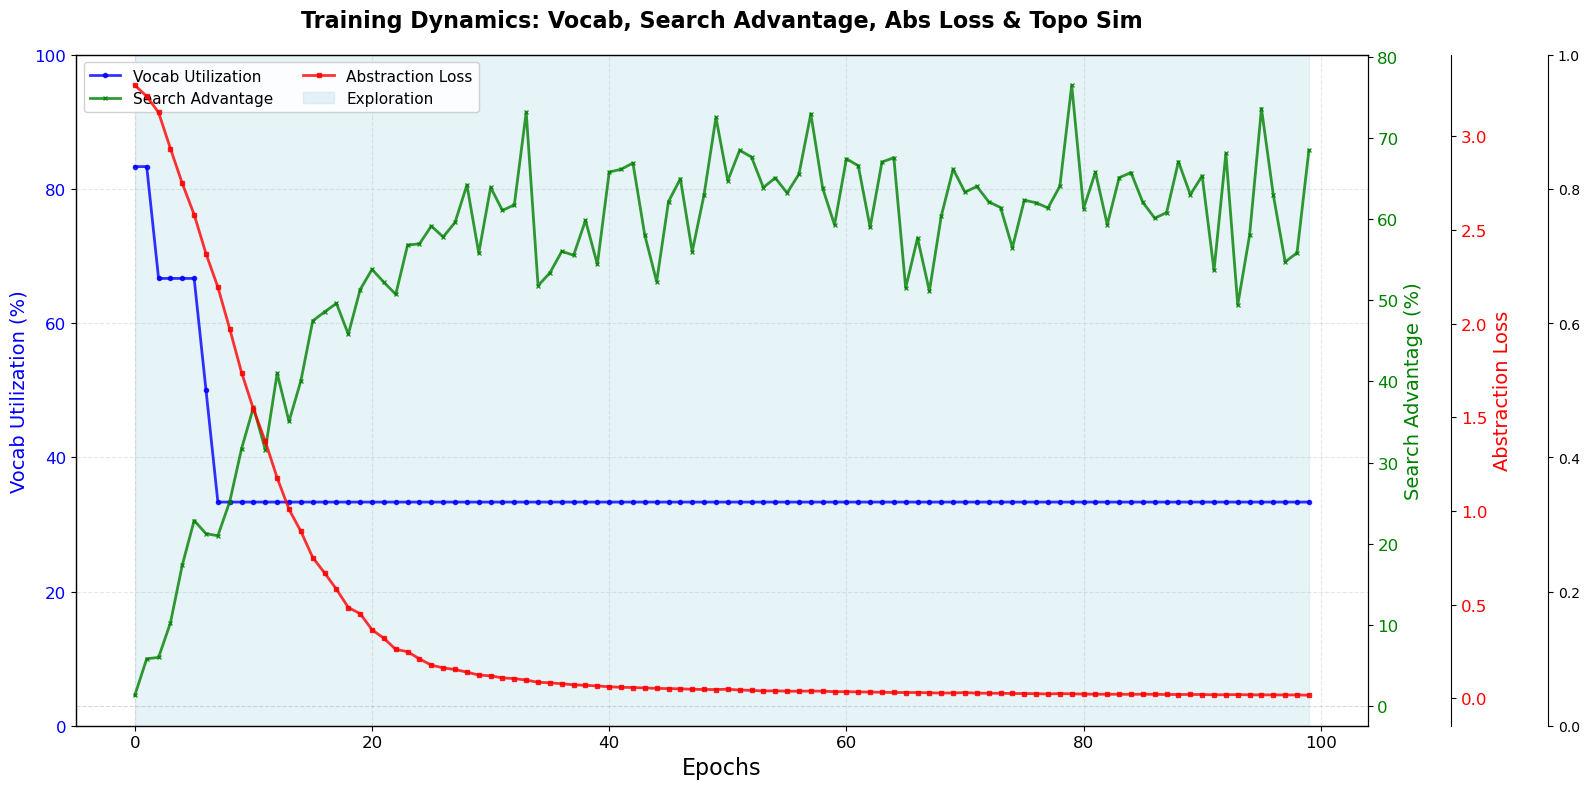

In [5]:
from sorl.stat import plot_training_metrics_combined

plot_training_metrics_combined(record)

In [ ]:
# Idea #1. 
# - currently we are doing 'per-document' selection, how about 'per-abstract' selection instead?
# - this way things are more granular, and the implementation is likely easier?

# Hypothesis #1. 
# - as sequence grows in length, coming up good abstract sentence in one-shot is more difficult. 
# - therefore, more local, more granular selection is more likely to work than 'per-document' selection. 
# - when building up abstraction, a ground-up approach might be more effective. 
# -> this partially explains the difference observed in local, small-scaled experiment and LM scale experiments. 
#  - per-doc abs search is drastically different from per-abstract abs search, local exp resembles later, LM scale experiment resembles former

# Implementation #1. 
# - built 'select best per abs' function for abstraction-level selection & utility assignment
# - each abs has its utility determined by the 'next K traj tokens' p(s_{t+1:t+K} | a_{t})
# - and we select the best abs based on best utility criterion provided above


In [ ]:
# Memory Compression Experiments 
# --> Another key to increase 'vocab utilization' and 'search advantage'
# ----------------------------------------------------------------------
from sorl.neo_utils import compute_weighted_loss, sorl_search_v4, compute_sgpo_loss_v2, sorl_evaluate_v2, compute_vocab_utilization_rate, compute_loss
from sorl.topo import uniformity_loss, contrastive_loss
from sorl.neo_utils import RunningRewardScaler, compute_partial_loss
from sorl.gapt import GatedPhaseTransition
import copy
from collections import defaultdict

# ------ SGPO + Topo regularization for emerging compositional abstraction structure -------
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)
scaler = RunningRewardScaler()


alpha_loss = 0.1
alpha_topo = 0.0
alpha_contrast = 1.0
adv_mode = 10 # encourage useful abstraction
w_util_greedy = 1.0
topo_mode = 0 # correlation target 
util_dist_mode = 1 # stop grad on worse rollout
n = 2
min_temperature = 0.0
min_train_temperature = 2.0
max_temperature = 5.0
temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
n_eval = 2 
temperatures_eval = torch.tensor([min_temperature, max_temperature], device=model.device)
temperatures_topo = torch.tensor([min_train_temperature, min_train_temperature], device=model.device)
K = 4
num_steps = 500
gapt = GatedPhaseTransition()

record = defaultdict(list)
vocab_util = 1.0
for step in range(num_steps): 

    memory_span = 1792
 
    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    # --- mixture of SoRL selection & deep supervision (avg. loss per iteration) ---
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv, abs_dist = sorl_search_v4(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures,
                                                                         mode=adv_mode, truncate_seq_len=False)
    # --- compute loss ---
    traj_loss, grpo_loss, g_abs_loss = compute_partial_loss(search_tokens, search_adv, model, memory_span, attn_blocksize, w_util_greedy, w_util_stochastic=0.5)

    contrast_loss = contrastive_loss(model.transformer.wte.weight[model.vocab_sizes[0]:])
    # contrast_loss = uniformity_loss(model.transformer.wte.weight[model.vocab_sizes[0]:])

    loss = traj_loss + alpha_loss * grpo_loss + alpha_contrast * contrast_loss + 0.01 * g_abs_loss
    print("traj (g + s) loss: ", traj_loss.item(), "stochastic rollout abs loss: ", grpo_loss.item(), "contrast loss: ", contrast_loss.item())

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, max_temperature], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss, topo_sim_greedy = sorl_evaluate_v2(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            _, _, _, _, topo_sim = sorl_evaluate_v2(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_topo,
                                                                     truncate_seq_len=False)
            traj_loss, abs_loss = compute_loss(val_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)
            vocab_util = compute_vocab_utilization_rate(val_tokens, model)
            record['vocab_util'].append(vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['traj_loss'].append(traj_loss.item())
            record['contrast_loss'].append(contrast_loss.item())
        print(f"\nvalidation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}% | topo_sim: {topo_sim.item():.2f} | contrast_loss: {contrast_loss.item():.2f}")

traj (g + s) loss:  3.295837163925171 stochastic rollout abs loss:  0.0 contrast loss:  1.6243940591812134

validation step 0 | traj_loss: 3.26 | abs_loss: 3.31 | search adv: 0.01% | vocab util: 83.33% | topo_sim: 0.05 | contrast_loss: 1.62
traj (g + s) loss:  3.2658302783966064 stochastic rollout abs loss:  0.8286990523338318 contrast loss:  1.6236934661865234
traj (g + s) loss:  3.2089955806732178 stochastic rollout abs loss:  1.846111536026001 contrast loss:  1.6229945421218872

validation step 2 | traj_loss: 3.11 | abs_loss: 3.42 | search adv: 0.07% | vocab util: 83.33% | topo_sim: 0.08 | contrast_loss: 1.62
traj (g + s) loss:  3.112708806991577 stochastic rollout abs loss:  1.3667142391204834 contrast loss:  1.6222983598709106
traj (g + s) loss:  2.9856173992156982 stochastic rollout abs loss:  1.944260835647583 contrast loss:  1.621604084968567

validation step 4 | traj_loss: 2.86 | abs_loss: 3.67 | search adv: 0.00% | vocab util: 66.67% | topo_sim: 0.07 | contrast_loss: 1.62
tra

In [ ]:
# Bold Exploration runs:
# Ver 1. stochastic rollout adv = ReLU(u_s - u_g), w_util_greedy = 1.0
# traj loss 1.12 | abs loss 8.84 | search adv: 0.88% | vocab util: 50-66%
# - it's clear that adv is too small in scale at mode 5, raw ReLU(u_diff) is too small to work (1e-3 at ~400 step, in comparison, traj loss ~1.1)
# - nonethless, we observe 83% vocab util at ~350 step, consistently remains there. 
# - search adv is ~0.88%

# Ver 2. stochastic rollout adv = min(ReLU((u_s-u_g)/u_s), 1.0), w_util_greedy = 1.0
# traj loss 1.12 | abs loss 8.53 | search adv: -0.01% | vocab util: 66%
# - vocab emerge, adjusted stochastic rollout abs loss ~3e-3 too
# - we losse the 'advantageous greedy' momentum -- so relative scale is not good, we should directly scale the Relu(u_diff)? 

# Ver 3. stochastic rollout adv = (u_s > u_g), w_util_greedy = 1.0
# traj loss 1.13 | abs loss 2.11 | search adv -0.97% | vocab util: 16.7-33.3% 
# - the relative term makes things unstable, abs_loss goes up and down, up an down. 

# Ver 4. stochastic rollout adv = ReLU(u_s - u_g) * 1000, clamp max 5.0, u_util_greedy = 1.0
# traj loss 1.13 | abs loss 1.66 | search adv 0.75% | vocab util: 16.7-33.3% 
# - here we observe vocabulary collapse, at the same time abs loss converges

# Ver 5. stochastic rollout adv = ReLU(u_s - u_g) * 10, w_util_stochastic = 0.5 
# - weaker signal for predicting random, better rollout can establish more advantage on the greedy rollout? 
# traj loss 1.12 | abs loss 9.61 | search adv: 0.12% | vocab util: 50.0% 

# Ver 6. stochastic rollout adv = ReLU(u_s - u_g) * 10, w_util_stochastic = 1.0, bring back 0.01 * greedy_abs_loss
# similar

# Ver 7. stochastic rollout adv = ReLU(u_s - u_g) * 10, w_util_stochastic = 1.0, bring back 0.1 * greedy_abs_loss
# similar 

# Ver 8. adv \propto p(s|a), but we zero out exploration penalty for stochastic rollout
# abs loss 2.08 | search adv -0.02% | vocab util 33%

# Ver 9. adv \propto p(s|a), but we 0.1 scales the exploration penalty for stochastic rollout
# traj_loss: 1.13 | abs_loss: 2.64 | search adv: 0.15% | vocab util: 33.33%


# So, now we loses on dominant greedy momentum? What if we bring back the 'reinforcement' on greedy rollout's predictability a bit here? 

# torch.exp(-1.6)
import math 
math.exp(-1.6)


0.20189651799465538

In [ ]:
# Anchor Loss (We want greedy to be advantageous, but not too confident)
import torch.nn.functional as F

def anchor_greedy_abs_loss(greedy_abs_loss): 
    anchor_weight = 0.1
    loss_anchor = anchor_weight * greedy_abs_loss
    target_nll = 0.3 
    penalty_weight = 2.0 # Strong kick if it gets too confident
    confidence_penalty = penalty_weight * F.relu(target_nll - greedy_abs_loss)
    total_greedy_loss = loss_anchor + confidence_penalty
    return total_greedy_loss

In [ ]:
# save model checkpoint
import torch

# checkpoint_path = "gat_model.pt"
checkpoint_path = "gat_model_d1.pt"
# torch.save(model.state_dict(), checkpoint_path)
# print(f"Model saved to {checkpoint_path}")


# load model checkpoint
ema_model = GAT(gat_config)
ema_model.load_state_dict(torch.load(checkpoint_path, map_location=ema_model.device))
ema_model.eval()
print(f"Model loaded from {checkpoint_path}")


# child model inherits same parameter, but have its abstraction wte & lm_head re-initialized
from sorl.neo_utils import reinit_model

model.load_state_dict(torch.load(checkpoint_path, map_location=model.device))
reinit_model(model, mode=0) # re-init abs wte & lm_head
# reinit_model(model, mode=4) # re-init all parameters | this is not aligned with model = GAT(gat_config) intiialization, we get different initial traj_loss

Model loaded from gat_model_d1.pt


In [ ]:
# -------------------------------------------------
# Distillation runs (Infer p(s | a) given p(a | s))
# --------------------------------------------------

from sorl.neo_utils import sorl_search_v3, sorl_search_v4, compute_sgpo_loss_v2, sorl_evaluate_v2, compute_vocab_utilization_rate, compute_loss, compute_weighted_loss
from sorl.topo import uniformity_loss, contrastive_loss
from sorl.gapt import GatedPhaseTransition
import copy
from collections import defaultdict

# ------ Off-line Distillation Runs -------
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)

batch_size = 16
memory_span = 2 * seq_len + 2
attn_blocksize = 1792
alpha_loss = 0.1
alpha_topo = 0.0
adv_mode = 0 # exploitation
topo_mode = 0 # correlation target 
util_dist_mode = 1 # stop grad on worse rollout
n = 2
min_temperature = 0.0
topo_temperature = 2.0
max_temperature = 2.0
temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
n_eval = 2 
temperatures_eval = torch.tensor([min_temperature, max_temperature], device=model.device)
temperatures_topo = torch.tensor([topo_temperature, topo_temperature], device=model.device)
K = 4
max_iterations = 2
num_steps = 200
gapt = GatedPhaseTransition()

record = defaultdict(list)
vocab_util = 1.0
for step in range(num_steps): 

    memory_span = (2 * seq_len + 2) - (step / num_steps) * (2 * seq_len + 2 - seq_len) 
    # memory_span = 1

    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    # --- mixture of SoRL selection & deep supervision (avg. loss per iteration) ---
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv, abs_dist = sorl_search_v4(tokens, ema_model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures,
                                                                         mode=adv_mode, truncate_seq_len=False)
    # --- compute loss ---
    traj_loss, abs_loss = compute_loss(search_tokens, model, memory_span, attn_blocksize)
    loss = traj_loss + alpha_loss * abs_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, max_temperature], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss, topo_sim_greedy = sorl_evaluate_v2(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            _, _, _, _, topo_sim = sorl_evaluate_v2(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_topo,
                                                                     truncate_seq_len=False)
            # contrast_loss = uniformity_loss(contrastive_loss(model.transformer.wte.weight[model.vocab_sizes[0]:]))
            contrast_loss = contrastive_loss(model.transformer.wte.weight[model.vocab_sizes[0]:])
            traj_loss, abs_loss = compute_loss(val_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)
            vocab_util = compute_vocab_utilization_rate(val_tokens, model)
            record['vocab_util'].append(vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['traj_loss'].append(traj_loss.item())
            # record['alpha_loss'].append(alpha_loss)
            # record['topo_sim'].append(topo_sim.item())
            # record['topo_sim_greedy'].append(topo_sim_greedy.item())
            # record['contrast_loss'].append(contrast_loss.item())
        print(f"\nvalidation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}% | topo_sim: {topo_sim.item():.2f} | contrast_loss: {contrast_loss.item():.2f}")


validation step 0 | traj_loss: 2.36 | abs_loss: 4.13 | search adv: -0.12% | vocab util: 33.33% | topo_sim: 0.04 | contrast_loss: 1.58

validation step 2 | traj_loss: 2.33 | abs_loss: 4.23 | search adv: -0.03% | vocab util: 33.33% | topo_sim: -0.03 | contrast_loss: 1.58

validation step 4 | traj_loss: 2.32 | abs_loss: 3.86 | search adv: 0.05% | vocab util: 33.33% | topo_sim: 0.06 | contrast_loss: 1.58

validation step 6 | traj_loss: 2.31 | abs_loss: 3.47 | search adv: -0.07% | vocab util: 33.33% | topo_sim: 0.10 | contrast_loss: 1.58

validation step 8 | traj_loss: 2.34 | abs_loss: 3.04 | search adv: 0.07% | vocab util: 33.33% | topo_sim: 0.10 | contrast_loss: 1.58

validation step 10 | traj_loss: 2.31 | abs_loss: 2.76 | search adv: 0.13% | vocab util: 33.33% | topo_sim: 0.02 | contrast_loss: 1.58

validation step 12 | traj_loss: 2.33 | abs_loss: 2.50 | search adv: 0.10% | vocab util: 33.33% | topo_sim: 0.02 | contrast_loss: 1.58

validation step 14 | traj_loss: 2.25 | abs_loss: 2.39 |

In [ ]:
# save model checkpoint
import torch

checkpoint_path = "gat_model_d1.pt"
# torch.save(model.state_dict(), checkpoint_path)
# print(f"Model saved to {checkpoint_path}")


# load model checkpoint
ema_model = GAT(gat_config)
ema_model.load_state_dict(torch.load(checkpoint_path, map_location=ema_model.device))
ema_model.eval()
print(f"Model loaded from {checkpoint_path}")


# child model inherits same parameter, but have its abstraction wte & lm_head re-initialized
from sorl.neo_utils import reinit_model

model.load_state_dict(torch.load(checkpoint_path, map_location=model.device))
# reinit_model(model, mode=0) # re-init abs wte & lm_head
# reinit_model(model, mode=4) # re-init all parameters | this is not aligned with model = GAT(gat_config) intiialization, we get different initial traj_loss

Model loaded from gat_model_d2.pt


<All keys matched successfully>

In [ ]:
# -------------------------------------------------
# Exploration Runs (Infer p(a | s) given p(s | a))
# --------------------------------------------------

from sorl.neo_utils import sorl_search_v5, sorl_search_v4, compute_sgpo_loss, sorl_evaluate_v2, compute_vocab_utilization_rate, compute_loss, compute_weighted_loss
from sorl.topo import uniformity_loss, contrastive_loss
from sorl.gapt import GatedPhaseTransition
import copy
from collections import defaultdict

# ------ Off-line Distillation Runs -------
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)

batch_size = 16
memory_span = 2 * seq_len + 2
attn_blocksize = 1792
alpha_loss = 0.1
alpha_topo = 0.0
adv_mode = 3 # exploitation
n = 2
min_temperature = 0.0
topo_temperature = 2.0
max_temperature = 5.0
temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
n_eval = 2 
temperatures_eval = torch.tensor([min_temperature, max_temperature], device=model.device)
temperatures_topo = torch.tensor([topo_temperature, topo_temperature], device=model.device)
K = 4
max_iterations = 2
num_steps = 400
gapt = GatedPhaseTransition()

record = defaultdict(list)
vocab_util = 1.0
for step in range(num_steps): 

    memory_span = (2 * seq_len + 2) - (step / num_steps) * (2 * seq_len + 2 - seq_len) 
    # memory_span = 1

    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    # --- mixture of SoRL selection & deep supervision (avg. loss per iteration) ---
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv = sorl_search_v5(tokens, model, ema_model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures,
                                                                         mode=adv_mode, truncate_seq_len=False)
    # --- compute loss ---
    # traj_loss, abs_loss = compute_loss(search_tokens, model, memory_span, attn_blocksize)
    traj_loss, abs_loss = compute_sgpo_loss(search_tokens, search_adv, model, memory_span, attn_blocksize)
    loss = traj_loss + alpha_loss * abs_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, max_temperature], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss, topo_sim_greedy = sorl_evaluate_v2(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            _, _, _, _, topo_sim = sorl_evaluate_v2(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_topo,
                                                                     truncate_seq_len=False)
            # contrast_loss = uniformity_loss(contrastive_loss(model.transformer.wte.weight[model.vocab_sizes[0]:]))
            contrast_loss = contrastive_loss(model.transformer.wte.weight[model.vocab_sizes[0]:])
            traj_loss, abs_loss = compute_loss(val_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)
            vocab_util = compute_vocab_utilization_rate(val_tokens, model)
            record['vocab_util'].append(vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['traj_loss'].append(traj_loss.item())
            # record['alpha_loss'].append(alpha_loss)
            # record['topo_sim'].append(topo_sim.item())
            # record['topo_sim_greedy'].append(topo_sim_greedy.item())
            # record['contrast_loss'].append(contrast_loss.item())
        print(f"\nvalidation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}% | topo_sim: {topo_sim.item():.2f} | contrast_loss: {contrast_loss.item():.2f}")


validation step 0 | traj_loss: 3.25 | abs_loss: 3.30 | search adv: 0.02% | vocab util: 50.00% | topo_sim: 0.06 | contrast_loss: 1.59

validation step 2 | traj_loss: 3.11 | abs_loss: 3.34 | search adv: 0.18% | vocab util: 50.00% | topo_sim: 0.13 | contrast_loss: 1.59

validation step 4 | traj_loss: 2.85 | abs_loss: 3.51 | search adv: 0.26% | vocab util: 16.67% | topo_sim: 0.11 | contrast_loss: 1.59

validation step 6 | traj_loss: 2.67 | abs_loss: 3.63 | search adv: 0.08% | vocab util: 16.67% | topo_sim: 0.14 | contrast_loss: 1.59

validation step 8 | traj_loss: 2.54 | abs_loss: 3.66 | search adv: 0.04% | vocab util: 16.67% | topo_sim: 0.05 | contrast_loss: 1.59

validation step 10 | traj_loss: 2.47 | abs_loss: 3.64 | search adv: 0.02% | vocab util: 16.67% | topo_sim: 0.00 | contrast_loss: 1.59

validation step 12 | traj_loss: 2.43 | abs_loss: 3.63 | search adv: 0.01% | vocab util: 16.67% | topo_sim: 0.03 | contrast_loss: 1.59

validation step 14 | traj_loss: 2.40 | abs_loss: 3.61 | sea

In [ ]:
# Fitting policy to the reward model again would work? 
# ----------------------------------------------------
# p(s | a)_parent --> p(s | a)_child | adv mode 3 p(s|a) | abs wte/proj re-init ==> collapsed vocabulary
# p(s | a) parent --> p(s | a) child | adv mode 3 p(s|a) | full re-init ==> search adv ~0%, vocab util ~16% (collapsed)
# - so brute-force exploitation is not a great idea?  
# p(s | a) parent --> p(s | a) child | adv mode 0 1/p(s|a) | abs wte/proj re-init ==> positive search adv observed ~9% (vocab util 33%), but then goes down to ~0%(vocab util1 16%)
# p(s | a) parent --> p(s | a) child | adv mode 0 1/p(s|a) | full re-init ==> search adv ~0%, vocab util ~ 16% (collpased)

# Distill one more time can improve search adv? 
# ---------------------------------------------
# baseline d1: search adv 1.85%, vocab util 33%
# d2: search adv 8.83% | vocab util 33% (search adv improves)
# d3: stagnating search_adv<10%


# Hmm... so the first question is not addressed yet :: how do we create that abstraction system in the first place? 
# --- it must be via compression, compression should be starting from 'lossless reconstruction' 
# Then the rest follows...

# We are not going towards the right direction here. The hacky exploration phase is not a natural appraoch here. 



In [ ]:
# Local experiment suggests 're-init' from scratch produces better 'search_adv' compared to 're-init' wte & lm_head only runs

# Idea #1. --> distill from a randomly initialized model. Locally this improves search adv, on LM experiments benefit disappears. 

# Issue #4. 
# - however, on server side, we did not observe search advantage being very positive. It's below 0% on the runs ... so what's missing? 
# To break down the problem, we can "store" checkpoint of the model (after SGPO), and load it into a separated 'distillation' script. 

# --- (a). load SGPO checkpoint, and do ablation on exploitation procedure on language modeling task --- 

# Idea #2. If we apply adv to both utility & predictability, can we improve search adv on greedy abstraction? 
# -- nope, locally we observe failure in improving search_adv --- they degrade utility. 

# --- adv applied to both utility & predictability? nope

 # Idea #4. EMA based distillation (semi-online) improves search_adv? Maybe not, I think 'memory compression' is more worthwhile as a route now. 

# Idea #5. 
# - What if during distillation (where abstraction is stable), we adds random masking, so that model could ONLY depends on these abstract tokens and nothing else? 
# - By squeezing the memory span, I observe a higher 'search adv' on abstraction, this resonates with LM experiment observation, it also meant
#   that if we can solve the 'lossless compression' problem, we can improve search adv on greedy abstraction. 

 # Idea #6. 
 # - (a). as supervision target, 'logit' based distillation is probably better than 'token' based distillation? 
 # - (b). adding random masking might help with 'lossless compression' here. 


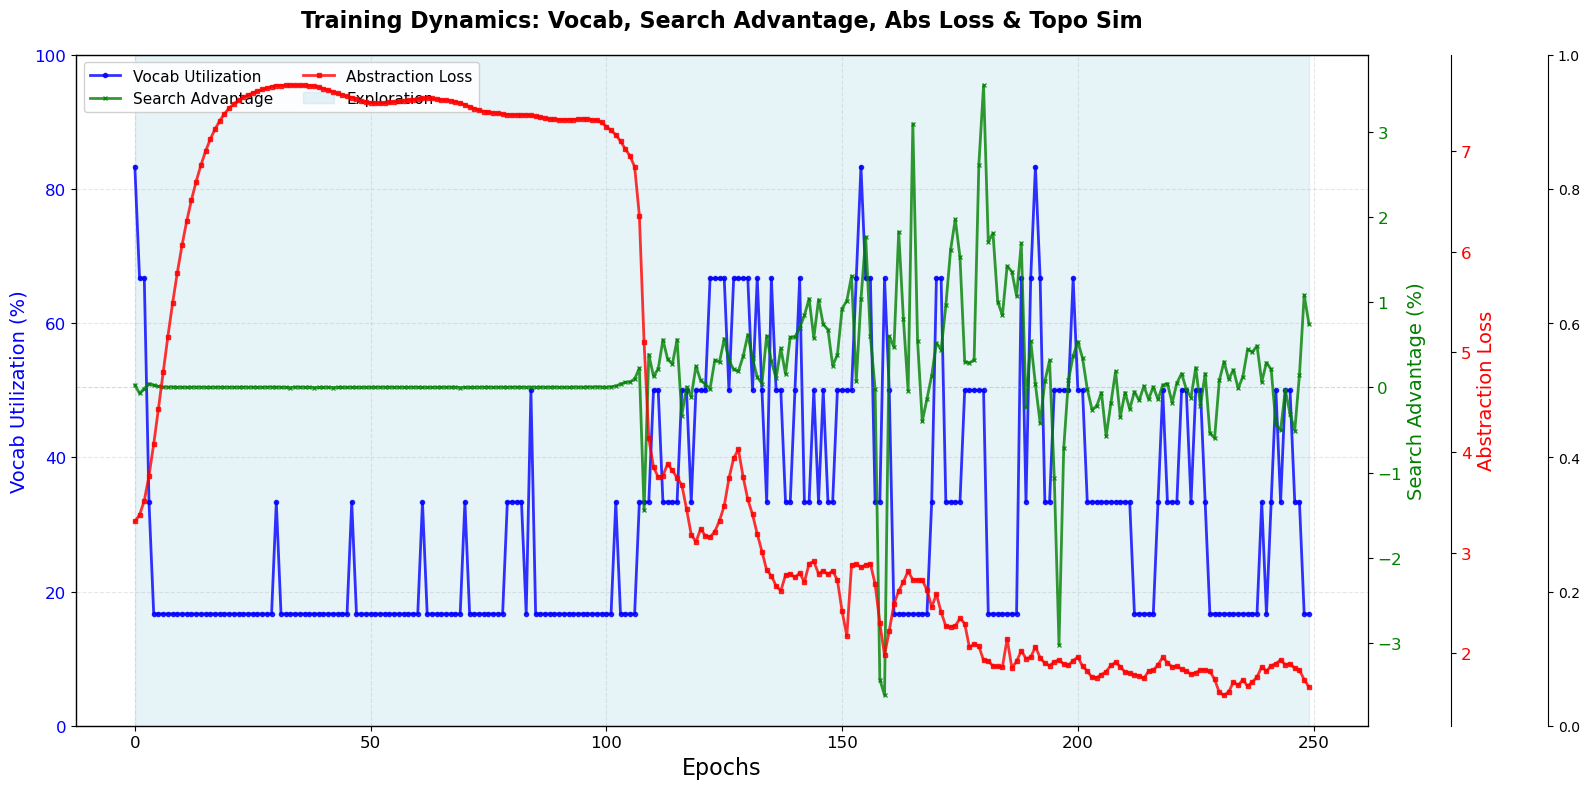

In [ ]:
from sorl.stat import plot_training_metrics_combined

plot_training_metrics_combined(record)

In [ ]:
# generate function implementation 
# ----------------------------------
from sorl.neo_utils import generate

tokens, loss_mask = loader.get_batch(1)
idx = tokens[:, :1 + seq_len].clone()
print(f"init   | idx: {idx[0].tolist()}")
for i in range(seq_len): 
    idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=torch.tensor(min_temperature))
    idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
    print(f"step {i+1} idx (abstraction free): {idx_without_abstraction.tolist()}")
    print(f"                         idx : {idx[0].tolist()}")

correct_cp = torch.allclose(idx_without_abstraction[1 : 1 + seq_len], idx_without_abstraction[1 + seq_len : 2 + 2*seq_len])
print(f"Copy correct: {correct_cp}")

init   | idx: [20, 1, 8, 5, 3, 6, 8, 6, 0, 4, 3, 2, 0, 1, 8, 0, 3]
step 1 idx (abstraction free): [20, 1, 8, 5, 3, 6, 8, 6, 0, 4, 3, 2, 0, 1, 8, 0, 3, 1]
                         idx : [20, 1, 8, 5, 3, 25, 6, 8, 6, 0, 25, 4, 3, 2, 0, 25, 1, 8, 0, 3, 25, 1]
step 2 idx (abstraction free): [20, 1, 8, 5, 3, 6, 8, 6, 0, 4, 3, 2, 0, 1, 8, 0, 3, 1, 8]
                         idx : [20, 1, 8, 5, 3, 25, 6, 8, 6, 0, 25, 4, 3, 2, 0, 25, 1, 8, 0, 3, 25, 1, 8]
step 3 idx (abstraction free): [20, 1, 8, 5, 3, 6, 8, 6, 0, 4, 3, 2, 0, 1, 8, 0, 3, 1, 8, 5]
                         idx : [20, 1, 8, 5, 3, 25, 6, 8, 6, 0, 25, 4, 3, 2, 0, 25, 1, 8, 0, 3, 25, 1, 8, 5]
step 4 idx (abstraction free): [20, 1, 8, 5, 3, 6, 8, 6, 0, 4, 3, 2, 0, 1, 8, 0, 3, 1, 8, 5, 3]
                         idx : [20, 1, 8, 5, 3, 25, 6, 8, 6, 0, 25, 4, 3, 2, 0, 25, 1, 8, 0, 3, 25, 1, 8, 5, 3]
step 5 idx (abstraction free): [20, 1, 8, 5, 3, 6, 8, 6, 0, 4, 3, 2, 0, 1, 8, 0, 3, 1, 8, 5, 3, 6]
                         idx : [20, 1,

In [ ]:
from sorl.eval import compute_vocab_utilization_rate

def eval_cp(model, tokens, K, max_iterations, memory_span, seq_len, loader, temperature=torch.tensor(0.5), num_samples=100):
    n_correct = 0
    abs_idx = []
    for _ in range(num_samples): 
        tokens, loss_mask = loader.get_batch(1)
        idx = tokens[:, :1 + seq_len].clone()
        for i in range(seq_len): 
            idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=temperature)
            idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
            abs_idx.append(idx[idx >= model.vocab_sizes[0]])
        correct_cp = torch.allclose(idx_without_abstraction[1 : 1 + seq_len], idx_without_abstraction[1 + seq_len : 2 + 2*seq_len])
        n_correct += correct_cp
    acc = n_correct / num_samples
    print(f"=== Copy & Paste Evaluation ===\n Copy correct: {acc * 100:.2f}%")

    data = torch.cat(abs_idx, dim=0)
    abs_util_rate = compute_vocab_utilization_rate(data, model)
    return acc, abs_util_rate


eval_cp(model, tokens, K, max_iterations, memory_span, seq_len, loader, num_samples=20)

=== Copy & Paste Evaluation ===
 Copy correct: 100.00%


(1.0, 0.8333333333333334)

 Total abs tokens: 6 | Unique abs tokens: 1 | Abs util rate: 16.67%


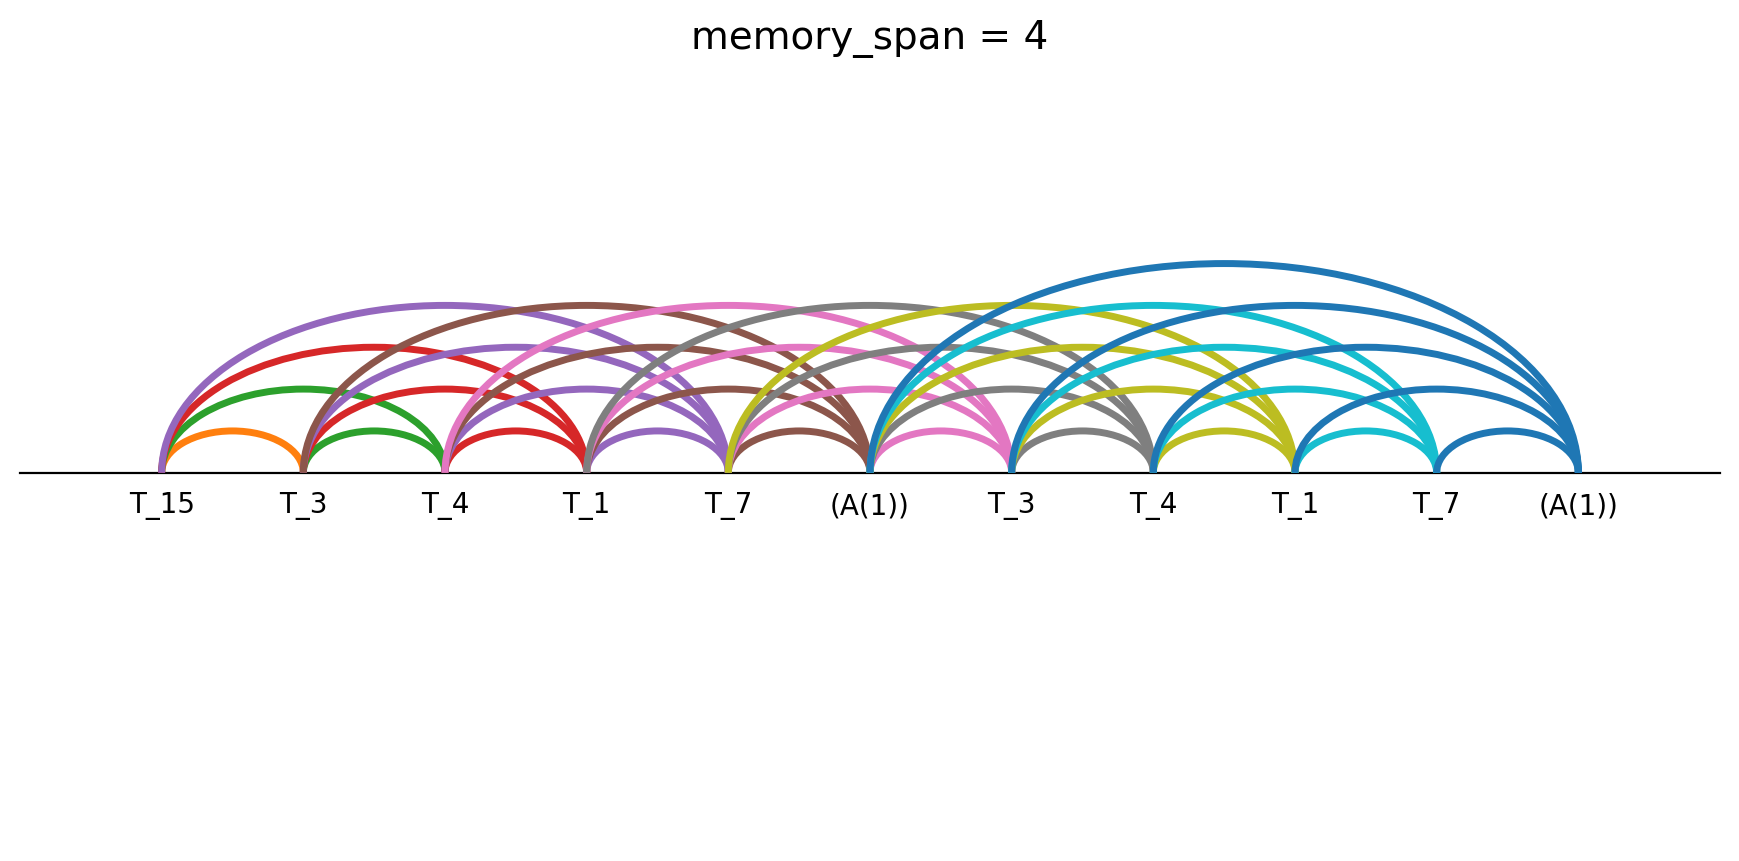

In [ ]:
# Simple 2D Attention Mask (without num_heads dimension)
# ======================================================

import torch
from sorl.neo_utils import sorl_search
from sorl.stat import plot_attn_arcs, materialize_attention_mask, AttentionMaskVisualizer

# Your existing variables
tokens, loss_mask = loader.get_batch(1)
with torch.no_grad(): 
    search_tokens, search_ppt, search_adv = sorl_search(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature,
                                                            truncate_seq_len=False)

# Generate 2D attention mask
levels = (search_tokens >= model.vocab_sizes[0]).long()
attn_mask = materialize_attention_mask(search_tokens, model, memory_span, attn_blocksize=1792)
visualizer = AttentionMaskVisualizer(search_tokens, model, attn_mask)

visualizer.plot_arcs(title=f"memory_span = {memory_span}")


In [ ]:
# heuristic rollout
import os, glob, itertools
from pathlib import Path

# MPS specific data loader functional (single device ver.)
# --------------------------------------------
def _load_data_shard(file: Path):
    header = torch.from_file(str(file), False, 256, dtype=torch.int32) # header is 256 int32
    assert header[0] == 20240520, "magic number mismatch in the data .bin file"
    assert header[1] == 1, "unsupported version"
    num_tokens = int(header[2]) # number of tokens (claimed)
    with file.open("rb", buffering=0) as f:
        tokens = torch.empty(num_tokens, dtype=torch.uint16, pin_memory=False) # MPS requires pin_memory=False
        f.seek(256 * 4)
        nbytes = f.readinto(tokens.numpy()) # avoid bytes->array copy by @YouJiacheng
        assert nbytes == 2 * num_tokens, "number of tokens read does not match header"
    return tokens

def data_generator(filename_pattern: str, sequence_length: int, device: str): 

    filename_pattern = "data/fineweb10B/fineweb_train_*.bin"
    files = [Path(file) for file in sorted(glob.glob(filename_pattern))]
    file_iter = itertools.cycle(files)
    tokens, pos = _load_data_shard(next(file_iter)), 0
    while True: 
        # Concern 1. Doesn't this means end-of-file is never reached?
        if pos + sequence_length + 1 >= len(tokens): # not enough data left -> load a new file
            tokens, pos = _load_data_shard(next(file_iter)), 0

        idx = tokens[pos : pos + sequence_length + 1].unsqueeze(0).to(device=device, dtype=torch.int32, non_blocking=True)
        pos += sequence_length
        yield idx


data = _load_data_shard(Path("data/fineweb10B/fineweb_train_000002.bin"))

train_loader = data_generator(filename_pattern="data/fineweb10B/fineweb_train_*.bin", sequence_length=256, device="cpu")
val_loader = data_generator(filename_pattern="data/fineweb10B/fineweb_val_000000.bin", sequence_length=256, device="cpu")

In [ ]:
from sorl.neo_utils import sorl_search_v2 

n = 2
K = 8
max_iterations=2
memory_span=1792
attn_blocksize=1792
temperature=10.0 

tokens = next(train_loader)

with torch.no_grad(): 
    search_tokens, search_ppt, search_adv, pt_curiosity = sorl_search_v2(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature)

In [ ]:
# --- Benchmark Speed & Memory Cost --- 
from sorl.benchmark import run_benchmark_suite
from sorl.neo_utils import sorl_search_v4
import torch 


# Levenshtein distance computation might've grabbed the majority of time
# --- it's current speed is un-acceptable. 